# Lab 3: Problem 2 — Employee Training Planning (0/1 Knapsack DP)

---

## 1. Dynamic Programming Formulation
- **Objective**: Select a subset of $n$ training modules with costs $c_i$ and benefits $b_i$ to maximize total benefit within a maximum training budget $B$. Each module can be selected at most once (0/1 constraint).
- **State Definition**: Let $DP[i][w]$ represent the **maximum achievable benefit** considering a subset of the first $i$ modules with available budget $w$ (where $0 \le i \le n$ and $0 \le w \le B$).
- **Base Cases**:
  - $DP[0][w] = 0$ for all $0 \le w \le B$ (Zero benefit if no modules are chosen).
  - $DP[i][0] = 0$ for all $0 \le i \le n$ (Zero benefit if budget is $0$).
- **Recurrence Relation (State Transition)**:
  $$DP[i][w] = \begin{cases} DP[i-1][w] & \text{if } c_i > w \quad (\text{module } i \text{ exceeds current budget}) \\ \max\Big(DP[i-1][w], \; DP[i-1][w - c_i] + b_i\Big) & \text{if } c_i \le w \quad (\text{choose between skipping or selecting module } i) \end{cases}$$


In [1]:
def employee_training_01_dp(modules, budget):
    """
    Bottom-up 0/1 Dynamic Programming with module subset reconstruction.
    modules: list of tuples (name, cost, benefit)
    budget: maximum training budget B
    """
    n = len(modules)
    dp = [[0] * (budget + 1) for _ in range(n + 1)]
    
    for i in range(1, n + 1):
        name, cost, benefit = modules[i - 1]
        for w in range(budget + 1):
            if cost <= w:
                dp[i][w] = max(dp[i - 1][w], dp[i - 1][w - cost] + benefit)
            else:
                dp[i][w] = dp[i - 1][w]
                
    # Reconstruct selected modules
    selected_modules = []
    w = budget
    total_cost = 0
    for i in range(n, 0, -1):
        if dp[i][w] != dp[i - 1][w]:
            name, cost, benefit = modules[i - 1]
            selected_modules.append(name)
            total_cost += cost
            w -= cost
            
    selected_modules.reverse()
    return dp[n][budget], total_cost, selected_modules

# Training modules from PDF Example
modules = [
    ("M1", 4, 7),
    ("M2", 6, 10),
    ("M3", 5, 8),
    ("M4", 3, 5)
]
budget = 10

max_benefit, total_cost, selected = employee_training_01_dp(modules, budget)

print("=== PDF Example Solution (Budget B = 10) ===")
print(f"Available Modules : {modules}")
print(f"Maximum Benefit   : {max_benefit}")
print(f"Total Cost        : {total_cost} / {budget}")
print(f"Selected Modules  : {selected}")

# Boundary Cases
print("\n--- Boundary Cases ---")
print(f"Budget 0 : {employee_training_01_dp(modules, 0)}")
print(f"Budget 2 (Below minimum module cost): {employee_training_01_dp(modules, 2)}")


=== PDF Example Solution (Budget B = 10) ===
Available Modules : [('M1', 4, 7), ('M2', 6, 10), ('M3', 5, 8), ('M4', 3, 5)]
Maximum Benefit   : 17
Total Cost        : 10 / 10
Selected Modules  : ['M1', 'M2']

--- Boundary Cases ---
Budget 0 : (0, 0, [])
Budget 2 (Below minimum module cost): (0, 0, [])


---

## 2. Complexity Analysis

| Metric | 2D Bottom-Up DP | Space-Optimized 1D DP |
| :--- | :--- | :--- |
| **Time Complexity** | $\mathcal{O}(n \cdot B)$ | $\mathcal{O}(n \cdot B)$ |
| **Auxiliary Space** | $\mathcal{O}(n \cdot B)$ | $\mathcal{O}(B)$ |
| **Module Reconstruction** | Direct via table backtracking in $\mathcal{O}(n)$ | Requires auxiliary storage or bitmask |

- **Time Complexity**: Filling the $(n+1) \times (B+1)$ DP table takes constant $\mathcal{O}(1)$ operations per state $\rightarrow \mathcal{O}(n \cdot B)$. Reconstructing the selected module subset takes $\mathcal{O}(n)$ time. Total time is $\mathcal{O}(n \cdot B)$.
- **Auxiliary Space Complexity**: Storing the 2D DP table requires $(n+1)(B+1)$ integer entries $\rightarrow \mathcal{O}(n \cdot B)$ space.


---

## 3. Empirical Execution Time Experimentation & Graphs
We evaluate execution time behavior:
1. Across **increasing budget $B$** ($B \in [100, 2000]$) for various module counts ($n = 20, 50, 100$).
2. Across **increasing module counts $n$** ($n \in [20, 300]$) for a fixed budget ($B = 1000$).


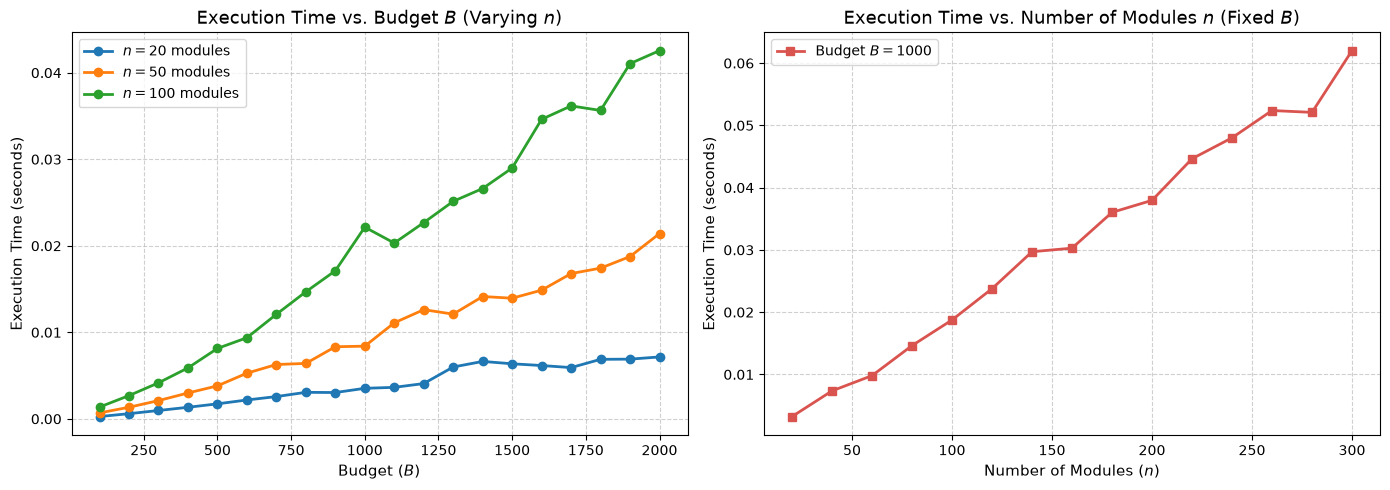

In [2]:
import time
import random
import matplotlib.pyplot as plt

random.seed(42)
def generate_modules(n):
    return [(f"M{i}", random.randint(1, 50), random.randint(5, 100)) for i in range(1, n + 1)]

# 1. Benchmark Execution Time vs. Budget B (Varying n)
budgets = list(range(100, 2001, 100))
module_counts = [20, 50, 100]
results_by_n = {n: [] for n in module_counts}

for n in module_counts:
    test_mods = generate_modules(n)
    for b in budgets:
        t0 = time.perf_counter()
        employee_training_01_dp(test_mods, b)
        results_by_n[n].append(time.perf_counter() - t0)

# 2. Benchmark Execution Time vs. Number of Modules n (Fixed B = 1000)
n_list = list(range(20, 301, 20))
fixed_b = 1000
times_vs_n = []
for n in n_list:
    test_mods = generate_modules(n)
    t0 = time.perf_counter()
    employee_training_01_dp(test_mods, fixed_b)
    times_vs_n.append(time.perf_counter() - t0)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Execution Time vs. Budget B
for n, times in results_by_n.items():
    axes[0].plot(budgets, times, 'o-', label=f'$n = {n}$ modules', linewidth=2)
axes[0].set_title('Execution Time vs. Budget $B$ (Varying $n$)', fontsize=13)
axes[0].set_xlabel('Budget ($B$)', fontsize=11)
axes[0].set_ylabel('Execution Time (seconds)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Graph 2: Execution Time vs. Module Count n
axes[1].plot(n_list, times_vs_n, 's-', color='#d9534f', linewidth=2, label=f'Budget $B = {fixed_b}$')
axes[1].set_title('Execution Time vs. Number of Modules $n$ (Fixed $B$)', fontsize=13)
axes[1].set_xlabel('Number of Modules ($n$)', fontsize=11)
axes[1].set_ylabel('Execution Time (seconds)', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


---

## 4. Analysis: Modification (Modules Selected More Than Once)

### Problem Formulation Change:
When each training module can be selected **multiple times**, the problem converts from **0/1 Knapsack** to **Unbounded Knapsack**.

### Changes in Recurrence Relation:
- **0/1 Recurrence**: Once module $i$ is taken, the remaining budget must be solved using only the first $i-1$ modules:
  $$DP[i][w] = \max\Big(DP[i-1][w], \; DP[i-1][w-c_i] + b_i\Big)$$
- **Unbounded Recurrence**: Module $i$ can be selected repeatedly, allowing transition from current state $w - c_i$:
  $$DP[w] = \max_{\substack{1 \le i \le n \\ c_i \le w}} \Big(DP[w - c_i] + b_i\Big)$$

### Effect on Complexity and Selection Behavior:
1. **Space Complexity**: Unbounded DP only needs a 1D array of size $\mathcal{O}(B)$ instead of 2D $\mathcal{O}(n \cdot B)$.
2. **Time Complexity**: Remains $\mathcal{O}(n \cdot B)$.
3. **Behavioral Difference**: The algorithm can repeatedly select high-efficiency modules (maximizing the ratio $\frac{b_i}{c_i}$) to achieve higher total benefit for the same budget.


In [3]:
def employee_training_unbounded_dp(modules, budget):
    """
    Unbounded Dynamic Programming where modules can be selected multiple times.
    """
    dp = [0] * (budget + 1)
    last_module = [-1] * (budget + 1)
    
    for w in range(1, budget + 1):
        for idx, (name, cost, benefit) in enumerate(modules):
            if cost <= w and dp[w - cost] + benefit > dp[w]:
                dp[w] = dp[w - cost] + benefit
                last_module[w] = idx
                
    # Reconstruct module choices
    selected = []
    curr = budget
    total_cost = 0
    while curr > 0 and last_module[curr] != -1:
        idx = last_module[curr]
        name, cost, benefit = modules[idx]
        selected.append(name)
        total_cost += cost
        curr -= cost
        
    return dp[budget], total_cost, selected

# Comparative Test on Budget = 12
b_test = 12
b01_val, b01_cost, b01_sel = employee_training_01_dp(modules, b_test)
unb_val, unb_cost, unb_sel = employee_training_unbounded_dp(modules, b_test)

print(f"=== Comparative Analysis on Budget B = {b_test} ===")
print(f"0/1 DP (At most once per module) : Benefit = {b01_val}, Cost = {b01_cost}, Modules = {b01_sel}")
print(f"Unbounded DP (Modules repeatable): Benefit = {unb_val}, Cost = {unb_cost}, Modules = {unb_sel}")


=== Comparative Analysis on Budget B = 12 ===
0/1 DP (At most once per module) : Benefit = 20, Cost = 12, Modules = ['M1', 'M3', 'M4']
Unbounded DP (Modules repeatable): Benefit = 21, Cost = 12, Modules = ['M1', 'M1', 'M1']
